In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, Wedge

(0.1, 0.2)

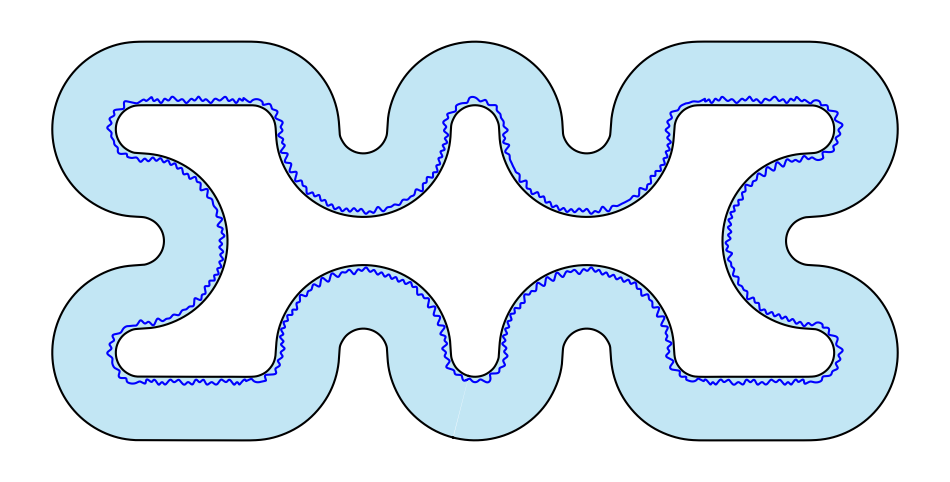

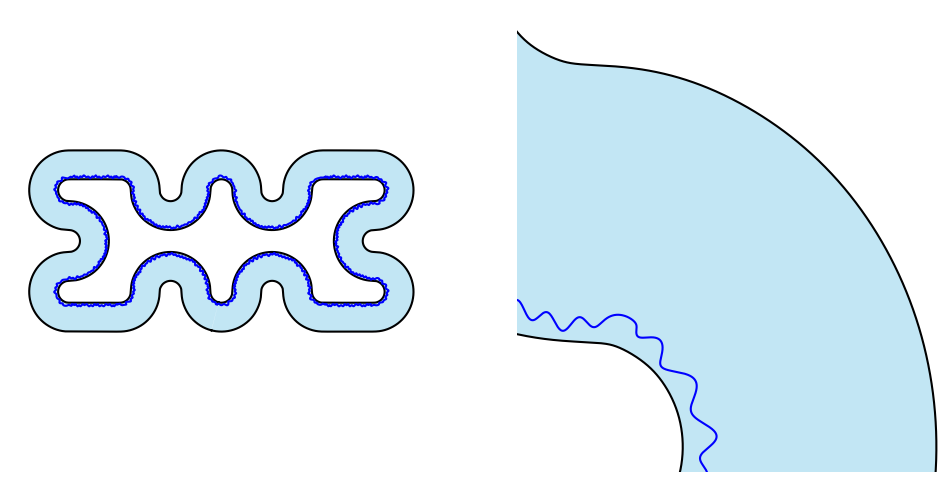

In [2]:
# numpy 1.26.4
# python 3.12.2
# scipy 1.12.0
# 

import jax
import jax.numpy as jnp
import numpy as np
from jax import random, vmap, grad, jit
from jax import lax
import matplotlib.pyplot as plt
import time
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Polygon
from matplotlib.collections import PatchCollection, PolyCollection
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import copy


def get_ctype_list(ctype):
    clist = [(ctype + i)%4 for i in [0, 0, -1, 1]]
    clist = np.roll(clist, ctype)
    return clist

def get_pytree(ctype, center_x, center_y, width, min_width):
    if (width <= min_width):
        return ((None), (ctype, center_x, center_y, width))
    else:
        ctype_list = get_ctype_list(ctype)
        center_x_list = tuple(center_x + p*width/4 for p in [1, -1, -1, 1])
        center_y_list = tuple(center_y + p*width/4 for p in [1, 1, -1, -1])
        widths = tuple(width/2 for _ in range(4))
        children = tuple(get_pytree(t, cx, cy, w, min_width) for t, cx, cy, w in zip(ctype_list, center_x_list, center_y_list, widths))
        return (children, (ctype, center_x, center_y, width))


def curve(t, t0, t1, tree, connect_type=(1, 1)):
    children = tree[0]
    ctype, cx, cy, w = tree[1]
    eventype = ctype % 2
    order = int(-1 + 2*eventype)
    
    

    connect_all = (connect_type[0], ) + tuple((i+ctype) % 2 for i in (1, 0, 1)) + (connect_type[1], )    
    
    
    if children is not None:
        t_seg = np.linspace(t0, t1, 5)
        ti = [t[np.where((t_s < t)*(t <= t_e))] for t_s, t_e in zip(t_seg[:-1], t_seg[1:])]
        children = tuple(children[(i+ctype+3) % 4] for i in range(4))
        return np.concatenate([curve(t, ts, te, child, (ct0, ct1)) for t, ts, te, ct0, ct1, child in \
                                zip(ti, t_seg[:-1], t_seg[1:], connect_all[:-1], connect_all[1:], children[::order])])
    else:
        t_norm = (t - t0)/(t1 - t0)
        cz = cx + 1j*cy
        z = w/4*np.exp(1j*(2*np.pi*order*t_norm-1*np.pi/2))
        
        if (connect_type[0] + ctype)%2 == 1: # Bend outwards
            z0 = order*w/4*np.ones_like(t_norm) - 1j *w/2 + 1j*w/2 * t_norm / 0.25
        else:
            z0 = order*w/2 + w/4*np.exp(-1j*np.pi/2 - 1j*order*t_norm*np.pi*2)
        
        if (connect_type[1] + ctype) % 2 == 1:
            z1 = -order*w/4*np.ones_like(t_norm) - 1j *w/2 + 1j*w/2 * (1.-t_norm) / 0.25
        else:
            z1 = -order*w/2 + w/4*np.exp(-1j*np.pi/2 + 1j*order*(1.-t_norm)*np.pi*2)
        
        rot = np.exp(1j*np.pi/2*ctype)
        z = np.where(t_norm < 0.25, z0, np.where(t_norm < 0.75, z, z1))
        z = cz + rot*z
        return z     
    
def double_curve(t, tree):
    z = np.concatenate([curve(t, 0, 0.5, tree), 1-curve(t-0.5, 0, .5, tree)])
    return z

def fill_between_complex_curves(z1, z2, color='skyblue', alpha=0.5, line_color='black'):
    """
    Fills the region between two complex-valued curves z1 and z2 in the complex plane.
    
    Parameters:
    - z1, z2: np.ndarray of complex numbers, same length
    - color: fill color
    - alpha: transparency
    - line_color: color of the boundary curves
    """
    assert len(z1) == len(z2), "z1 and z2 must have the same length"

    # Extract real and imaginary parts
    x1, y1 = np.real(z1), np.imag(z1)
    x2, y2 = np.real(z2), np.imag(z2)

    # Create the polygon by connecting z1 forward and z2 backward
    x = np.concatenate([x1, x2[::-1]])
    y = np.concatenate([y1, y2[::-1]])

    # Plot
    plt.fill(x, y, color=color, alpha=alpha, edgecolor='none')
    plt.plot(x1, y1, color=line_color)
    plt.plot(x2, y2, color=line_color)
    plt.axis("off")


confs = {
    "a": [0.2, 0.3, 0.8],
    "H": [0.005, 0.013, 0.03],
    "V": [1.0, 1.0, 1.0],
}

c_idx = 2
a = confs["a"][c_idx] # Detail size
H = confs["H"][c_idx] # Height of the roof
V = confs["V"][c_idx]  # Roof velocity



N = 200
tree = get_pytree(0, 0.5, 0.5, 1, a)
t = np.linspace(0, 1., N+1)[1:]

t_eval = np.linspace(0, 1., 10000+1)[1:]
t_fine_eval = np.linspace(0, 1., 20000+1)[1:]

z = 1j * double_curve(t, tree)
zmax = np.max(np.abs(z))
z = z / zmax * 0.5  # Normalize to fit in unit circle

zfft = jnp.fft.fft(z)
freq = jnp.fft.fftfreq(N, 1/N)
zfunc = lambda t: jnp.sum(zfft * jnp.exp(1j * 2 * np.pi * freq * t)) / N

def curvature_func(zfunc):
    def curvature(t):
        d2z = grad(grad(zfunc, holomorphic=True), holomorphic=True)(t + 0j)
        dz = grad(zfunc, holomorphic=True)(t + 0j)
        norm = jnp.abs(dz)
        det = dz.real * d2z.imag - dz.imag * d2z.real
        #curvature_value = jnp.abs(d2z) / (norm**3 + 1e-10)  # Avoid division by zero
        curvature_value = jnp.abs(det) / (norm**3 + 1e-3)  # Avoid division by zero
        return curvature_value
    return curvature


def normal_func(zfunc):
    def normal(t):
        dz = grad(zfunc, holomorphic=True)(t + 0j)
        norm = jnp.sqrt(dz.real**2 + dz.imag**2)
        return dz / (1j * norm)
    return normal

def tangent_func(zfunc):
    def tangent(t):
        dz = grad(zfunc, holomorphic=True)(t + 0j)
        norm = jnp.sqrt(dz.real**2 + dz.imag**2)
        return dz / norm
    return tangent

normal = normal_func(zfunc)
outside_fcn = lambda t: zfunc(t) - H * normal(t)
inside_fcn = lambda t: zfunc(t) + H * normal(t)
inside_crv = curvature_func(inside_fcn)
inside_normal = normal_func(inside_fcn)
outside_tangent = tangent_func(outside_fcn)


eps = 0.1 * H
eps_freq = int(0.8 / eps)
prod = lambda z: jnp.sin(z.real*eps_freq) * jnp.sin(z.imag*eps_freq)
amplitude = lambda t: 1.#/(1 + jnp.exp(c * (inside_crv(t) - d)))
roughness = lambda t: eps * (1.7 + prod((1+2j)*inside_fcn(t)))  * amplitude(t) # Roughness function, can be modified
rough_fcn = lambda t: inside_fcn(t) - roughness(t)*inside_normal(t)


vel_fcn = lambda t: V * outside_tangent(t)


zt = vmap(zfunc)(t_eval)
nt = vmap(normal)(t_eval)

zft = vmap(outside_fcn)(t_eval)
zrt = vmap(inside_fcn)(t_eval)

rft = vmap(rough_fcn)(t_fine_eval)


#plt.plot(t_eval, vmap(amplitude)(t_eval), label='Curvature', color='orange')
# Plot the curves to illustrate the domain
plt.figure(figsize=(12, 6))
fill_between_complex_curves(zft, zrt, color='skyblue', alpha=0.5, line_color='black')
plt.plot(rft.real, rft.imag, color='blue', label='Rough Roof')
plt.axis("equal")


plt.figure(figsize=(12, 6))

plt.subplot(121)
fill_between_complex_curves(zft, zrt, color='skyblue', alpha=0.5, line_color='black')
plt.plot(rft.real, rft.imag, color='blue', label='Rough Roof')
plt.axis("equal")

plt.subplot(122)
fill_between_complex_curves(zft, zrt, color='skyblue', alpha=0.5, line_color='black')
plt.plot(rft.real, rft.imag, color='blue', label='Rough Roof')
plt.xlim(0.3, 0.4)
plt.ylim(0.1, 0.2)
#plt.axis("equal")


In [35]:
import pygmsh as pg
import dolfin as dl
import numpy as np
import matplotlib.pyplot as plt
from hmm.stokes_fenics import StokesMacProb, StokesData, MacroSol, MacroSolver, StokesMicProb, MicroSolver, StokesHMMProblem, macro_to_micro, micros_to_macro
from hmm.hmm import IterativeHMMSolver
from util.basis_scaled import FourBasis, ScaleShiftedBasis
from util.mesh_tools import Box, order_connected_vertices, boundary_bbox_tree, find_intersection_on_segment, plot_boundary_mesh
from util.random import smooth_random_loop_fourier_coef, fourierGP_2D_lerp
from util.logger import EventTracker
from util.plot_tools import remove_axes
from dataclasses import dataclass
import meshio
import gmsh
from hmm.stokes_deep_fenics import DeepMicroSolverFenics, get_net
from typing import List, Tuple, Callable, Dict, Optional, Union

np.random.seed(0)
MESH_PATH = "/home/emastr/deep-micro-slip-model/data/mesh/"
figures_dir = "/home/emastr/deep-micro-slip-model/data/figures/"
simulation_dir = "/home/emastr/deep-micro-slip-model/data/stokes_fenics/"

def curvature_func(zfunc):
    def curvature(t):
        d2z = grad(grad(zfunc, holomorphic=True), holomorphic=True)(t + 0j)
        dz = grad(zfunc, holomorphic=True)(t + 0j)
        norm = jnp.abs(dz)
        det = dz.real * d2z.imag - dz.imag * d2z.real
        #curvature_value = jnp.abs(d2z) / (norm**3 + 1e-10)  # Avoid division by zero
        curvature_value = jnp.abs(det) / (norm**3 + 1e-3)  # Avoid division by zero
        return curvature_value
    return curvature

def normal_func(zfunc):
    def normal(t):
        dz = grad(zfunc, holomorphic=True)(t + 0j)
        norm = jnp.sqrt(dz.real**2 + dz.imag**2)
        return dz / (1j * norm)
    return normal

def tangent_func(zfunc):
    def tangent(t):
        dz = grad(zfunc, holomorphic=True)(t + 0j)
        norm = jnp.sqrt(dz.real**2 + dz.imag**2)
        return dz / norm
    return tangent

def list_sum(lists):
    return [item for sublist in lists for item in sublist]

def create_mesh(mesh, cell_type, prune_z=False):
    cells = mesh.get_cells_type(cell_type)
    cell_data = mesh.get_cell_data("gmsh:physical", cell_type)
    points = mesh.points[:,:2] if prune_z else mesh.points
    out_mesh = meshio.Mesh(points=points, cells={cell_type: cells}, cell_data={"name_to_read":[cell_data]})
    return out_mesh


class CurveDomain(dl.SubDomain):        
    def __init__(self, x, tol, bdry=True):
        self.x_curve = x
        self.tol = tol
        self.bdry = bdry
        super(CurveDomain, self).__init__()
        
    def inside(self, x, on_boundary):
        return on_boundary
        #if self.bdry:
        #    return bool(dl.near(dl.point_distance(x, self.x_curve), 0, self.tol) and on_boundary)
        #else:
        #    return bool(dl.point_distance(x, self.x_curve) <= self.tol)


class UnionDomain(dl.SubDomain):
    def __init__(self, domains):
        self.domains = domains
        super(UnionDomain, self).__init__()
    
    def inside(self, x, on_boundary):
        return bool(any([domain.inside(x, on_boundary) for domain in self.domains]))


@dataclass
class RoughTube:
    # Main parameters
    H: float
    a: float
    eps: float

    # Discrete points
    inner_points: np.ndarray = None
    outer_points: np.ndarray = None
    roughness_points: np.ndarray = None
    
    # File names
    name: str = ""
    rough_name: str = ""
    
    @staticmethod
    def from_main_pars(H, a, eps, name):
        N = 200
        Neval = 1000
        Nrough = 5000
        
        eps_freq = int(0.8 / eps)
        tree = get_pytree(0, 0.5, 0.5, 1, a)
        
        t = np.linspace(0, 1., N+1)[1:]
        z = 1j * double_curve(t, tree)
        z = z - jnp.mean(z)
        zmax = np.max(np.abs(z))
        z = z / zmax * 0.5  # Normalize to fit in unit circle
        zfft = jnp.fft.fft(z)
        freq = jnp.fft.fftfreq(N, 1/N)
        zfunc = lambda t: jnp.sum(zfft * jnp.exp(1j * 2 * np.pi * freq * t)) / N
            
        normal = normal_func(zfunc)
        outside_fcn = lambda t: zfunc(t) - H * normal(t)
        inside_fcn = lambda t: zfunc(t) + H * normal(t)
        inside_normal = normal_func(inside_fcn)

        prod = lambda z: jnp.sin(z.real*eps_freq) * jnp.sin(z.imag*eps_freq)
        roughness = lambda t: eps * (1.5 + prod((1+2j)*inside_fcn(t))) 
        rough_fcn = lambda t: inside_fcn(t) - roughness(t)*inside_normal(t)
        
        t_eval = np.linspace(0, 1., Neval+1)[1:]
        zft = vmap(outside_fcn)(t_eval)
        zrt = vmap(inside_fcn)(t_eval)
        
        t_fine_eval = np.linspace(0, 1., Nrough+1)[1:]
        rft = vmap(rough_fcn)(t_fine_eval)
        
        #zft = np.exp(1j * np.pi * 2 * t_eval)
        #zrt = np.exp(1j * np.pi * 2 * t_eval)*0.5
        #rft = np.exp(1j * np.pi * 2 * t_fine_eval)*0.55
        
        x_outside = np.array([zft.real, zft.imag]).T
        x_inside = np.array([zrt.real, zrt.imag]).T
        x_rough = np.array([rft.real, rft.imag]).T        
        return RoughTube(H, a, eps, x_inside, x_outside, x_rough, name=name, rough_name=name)
    
    
    
    def create_domains(self, TOL=0.01):
        outer = CurveDomain(self.outer_points, TOL, False)
        inner = CurveDomain(self.inner_points, TOL, False)
        outer_bdry = CurveDomain(self.outer_points, TOL, True)
        inner_bdry = CurveDomain(self.inner_points, TOL, True)
        return outer, inner, outer_bdry, inner_bdry
    
    
    @staticmethod
    def curve_loop(geom, points, lcar):
        N = points.shape[0]
        geom_points = []
        for x in points:
            if lcar is None:
                geom_points.append(geom.add_point([x[0], x[1]]))
            else:
                geom_points.append(geom.add_point([x[0], x[1]], lcar))
        #s1 = geom.add_bspline(geom_points[:N//3+1])
        #s2 = geom.add_bspline(geom_points[N//3:] + [geom_points[0]])
        curve = geom.add_bspline(geom_points + [geom_points[0]])
        l  = geom.add_curve_loop([curve])
        return l
    
    
    def save_geometry(self, file_name, scale=None):
        if scale is None:
            scale = self.H*0.5
        
        # Create the geometry
        with pg.geo.Geometry() as geom:
            outer = self.curve_loop(geom, self.outer_points, lcar=scale)
            inner = self.curve_loop(geom, self.inner_points, lcar=scale)
            
            surf = geom.add_plane_surface(outer, holes=[inner])
            geom.add_physical(surf, label='Inside')
            geom.add_physical(outer.curves, label='Dirichlet')
            geom.add_physical(inner.curves, label='Roughness')
                        
            mesh = geom.generate_mesh(dim=2)
            gmsh.write(f'{MESH_PATH}tube_temp.msh')        
        
        mesh = meshio.read(f'{MESH_PATH}tube_temp.msh')
        
        bdry = create_mesh(mesh, "line", True)
        mesh = create_mesh(mesh, "triangle", True)
        
        meshio.write(f'{MESH_PATH}{file_name}_tube_volume.xdmf', mesh)
        meshio.write(f'{MESH_PATH}{file_name}_tube_boundary.xdmf', bdry)
        self.name = file_name
        
    
    def create_roughness(self, file_name, scale=None):
        if scale is None:
            scale = self.eps
        with pg.geo.Geometry() as geom:
            l  = self.curve_loop(geom, self.roughness_points, scale)
            geom.add_physical(l.curves, label='Roughness')
            mesh = geom.generate_mesh(dim=1)
            gmsh.write(f'{MESH_PATH}tube_temp.msh')        
        
        mesh = meshio.read(f'{MESH_PATH}tube_temp.msh')
        mesh = create_mesh(mesh, "line", True)
        meshio.write(f'{MESH_PATH}{file_name}_tube_roughness.xdmf', mesh)
        self.rough_name = file_name
    
    
    def load_meshes(self):
        file = dl.XDMFFile(f'{MESH_PATH}{self.name}_tube_volume.xdmf')
        mesh = dl.Mesh()
        file.read(mesh)

        bdry_file = dl.XDMFFile(f'{MESH_PATH}{self.name}_tube_boundary.xdmf')
        bdry = dl.Mesh()
        bdry_file.read(bdry)

        rough_file = dl.XDMFFile(f'{MESH_PATH}{self.rough_name}_tube_roughness.xdmf')
        bdry_rough = dl.Mesh()
        rough_file.read(bdry_rough)
        return mesh, bdry, bdry_rough
    
    



        

(-0.5, 0.0)

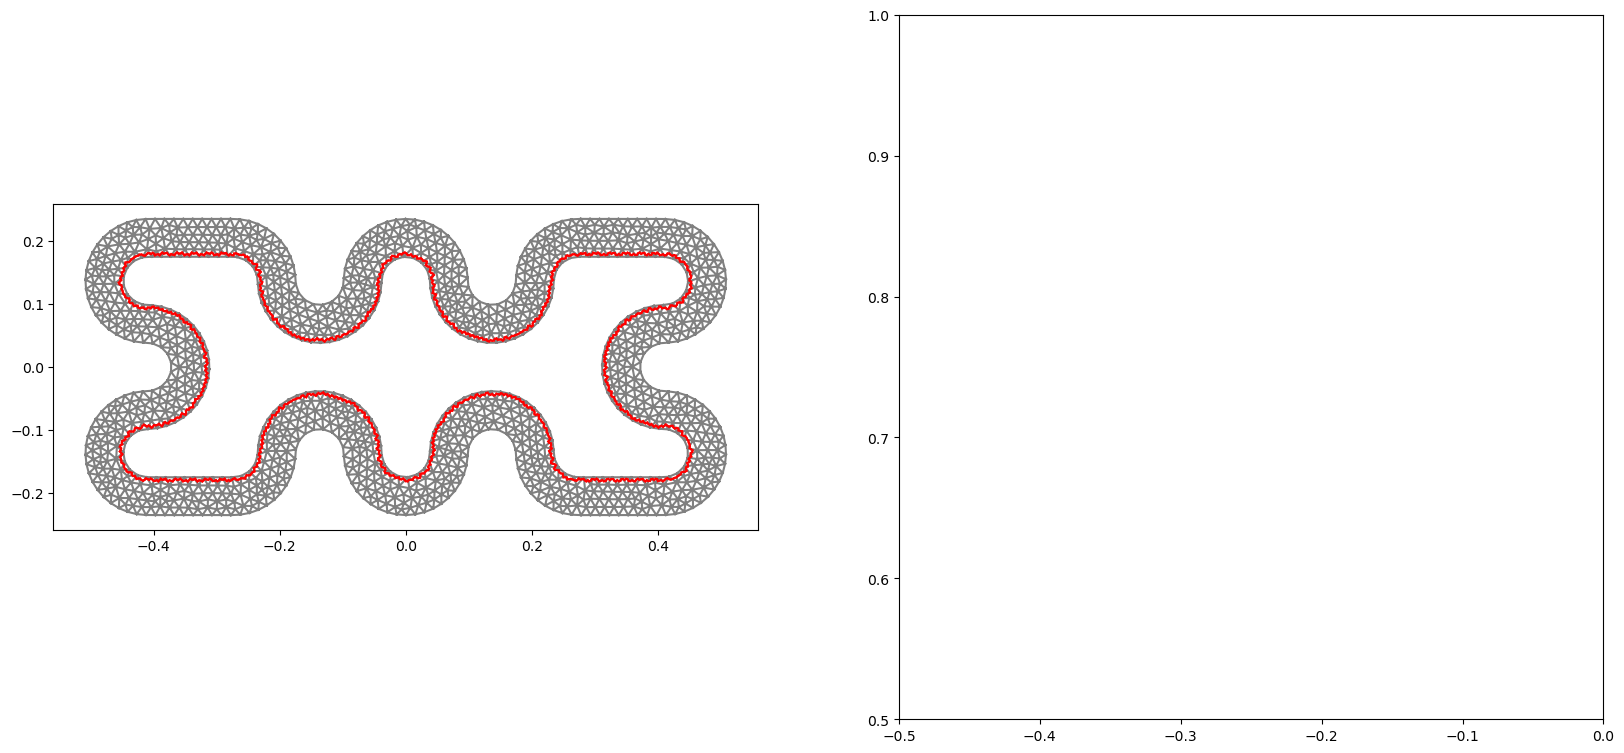

In [36]:
confs = {
    "a": [0.2, 0.3, 0.8],
    "H": [0.005, 0.013, 0.03],
    "V": [1.0, 1.0, 1.0],
}

c_idx = 2
a = confs["a"][c_idx] # Detail size
H = confs["H"][c_idx] # Height of the roof
V = confs["V"][c_idx]  # Roof velocity
eps = 0.1 * H

data = RoughTube.from_main_pars(H, a, eps, name='test_mesh')

#### ROUGHNESS FUNCTION ####
data.create_roughness('test_mesh_2')
data.save_geometry('test_mesh')
mesh, bdry, bdry_rough = data.load_meshes()
outer, inner, outer_bdry, inner_bdry = data.create_domains(TOL=0.01)


plt.figure(figsize=(20, 10))

plt.subplot(121)
dl.plot(mesh)
plot_boundary_mesh(bdry_rough, color='r')

plt.subplot(122)
dl.plot(mesh)
plot_boundary_mesh(bdry_rough, color='r')
plt.ylim([0.5, 1.0])
plt.xlim([-0.5, 0])

### Problem Formulation

In [37]:
# Define the function spaces
P2 = dl.VectorElement(family='P', cell=dl.triangle, degree=2)
P1 = dl.FiniteElement(family='P', cell=dl.triangle, degree=1)
P2P1 = P2 * P1
W = dl.FunctionSpace(mesh, P2P1)
U, P = W.split() 
Ux, Uy = U.split()

# Boundary Conditions
bcu_outer = dl.DirichletBC(U, dl.Expression((f'0', f'0'), degree=2), outer_bdry)
bcu_inner = dl.DirichletBC(U, dl.Constant((0., 0.)), inner_bdry)

stokes_data = StokesData.from_mesh(mesh, inner_bdry, bdry_rough, W, [bcu_inner, bcu_outer])

alpha_means = []
    
class GaussianRBFInterp:
    def __init__(self, x, a, scale=1.0):
        self.a = a
        self.scale = scale
        self.basis = lambda y: np.array([self.rbf(x_, y) for x_ in x])
        
        
    def __call__(self, x, y):
        xy = np.array([x, y])
        basis = self.basis(xy)
        return np.dot(basis, self.a) / np.sum(basis)
    
    def rbf(self, x, y):
        return np.exp(-np.linalg.norm(x - y)**2 / self.scale**2)
        


def interp(x, a):
    
    return GaussianRBFInterp(x, [-a_ for a_ in a], scale=2e-1)
    #return lambda x, y: amean #basis(np.array([x]))[0]
    #return micros_to_macro(x, [-s for s in a], scale=1.0)
    #return lambda x,y: amean#: basis(np.array([x]))[0]

Nmic = 100
mac = StokesMacProb(stokes_data, interp=interp, alpha0=lambda x,y: 0.01, lam=1e3)
mac_solver = MacroSolver()
projection_op = lambda *args: macro_to_micro(*args, N=7)
pts = data.get_micro_points(Nmic)
micros = []
for pt in pts:
    mic = StokesMicProb(stokes_data, pt, projection_op=projection_op, debug=False, width=0.02, height=0.02, corner_w=0.006, pad=0.03, n_refine=2)
    micros.append(mic)
hmm_prob = StokesHMMProblem(mac, micros, data)

ValueError: No boundary found